In [88]:
import kagglehub
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Seed
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Download dataset
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
print("Path to dataset files:", path)

# Load data
df = pd.read_csv(f"{path}/diabetes.csv")

# Replace impossible zero values
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[zero_cols] = df[zero_cols].replace(0, np.nan)

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Train/test split: 15% test = 116 samples
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=SEED,
    stratify=y
)

# Impute missing values
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Class weights
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, weights))

# ANN model
model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.15),

    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.10),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=30,
    mode="max",
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=0.00001
)

# Train
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=250,
    batch_size=16,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights,
    verbose=1
)

# Evaluate
test_loss, test_accuracy, test_auc = model.evaluate(X_test, y_test, verbose=0)

test_probs = model.predict(X_test, verbose=0).ravel()
test_preds = (test_probs >= 0.5).astype(int)

print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
print(f"ROC-AUC Score: {test_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_preds))

print("\nClassification Report:")
print(classification_report(y_test, test_preds, digits=4))

# Save model and preprocessing
model.save("diabetes_ann_model.keras")
model.save("diabetes_ann_model.h5")

joblib.dump(
    {
        "imputer": imputer,
        "scaler": scaler,
        "threshold": 0.5,
        "zero_cols": zero_cols
    },
    "diabetes_preprocessing.joblib"
)

print("\nSaved model: diabetes_ann_model.keras")
print("Saved model: diabetes_ann_model.h5")
print("Saved preprocessing: diabetes_preprocessing.joblib")

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-database
Epoch 1/250
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5739 - auc: 0.6615 - loss: 0.6813 - val_accuracy: 0.7023 - val_auc: 0.7616 - val_loss: 0.6413 - learning_rate: 0.0010
Epoch 2/250
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7102 - auc: 0.7907 - loss: 0.5613 - val_accuracy: 0.7099 - val_auc: 0.8092 - val_loss: 0.5750 - learning_rate: 0.0010
Epoch 3/250
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7217 - auc: 0.8179 - loss: 0.5188 - val_accuracy: 0.7176 - val_auc: 0.8083 - val_loss: 0.5388 - learning_rate: 0.0010
Epoch 4/250
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7409 - auc: 0.8222 - loss: 0.5190 - val_accuracy: 0.7099 - val_auc: 0.8057 - val_loss: 0.5204 - learning_rate: 0.0010
Epoch 5/250
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7370 - auc: 0.8373 - loss: 0.4958 - val_accuracy:


Test Accuracy: 79.31%
ROC-AUC Score: 0.8589

Confusion Matrix:
[[63 13]
 [11 29]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8514    0.8289    0.8400        76
           1     0.6905    0.7250    0.7073        40

    accuracy                         0.7931       116
   macro avg     0.7709    0.7770    0.7737       116
weighted avg     0.7959    0.7931    0.7942       116


Saved model: diabetes_ann_model.keras
Saved model: diabetes_ann_model.h5
Saved preprocessing: diabetes_preprocessing.joblib


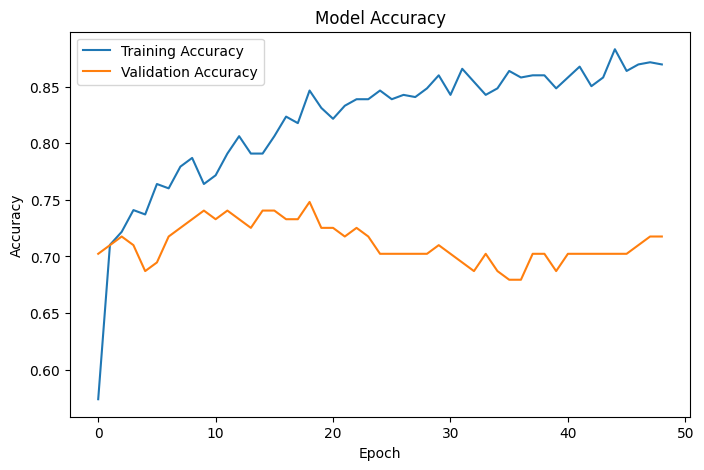

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

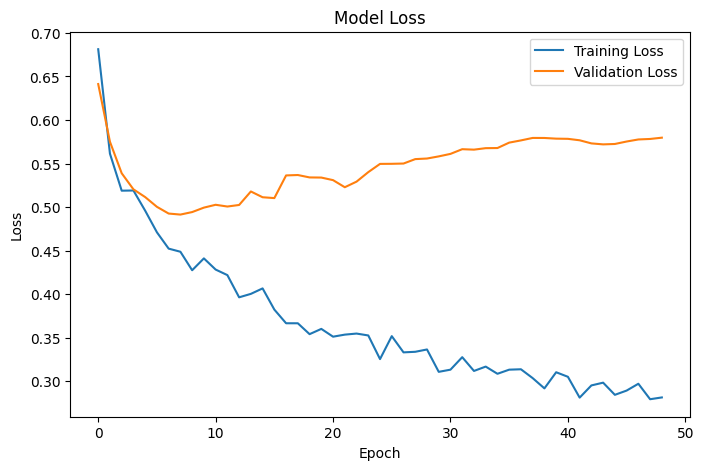

In [90]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

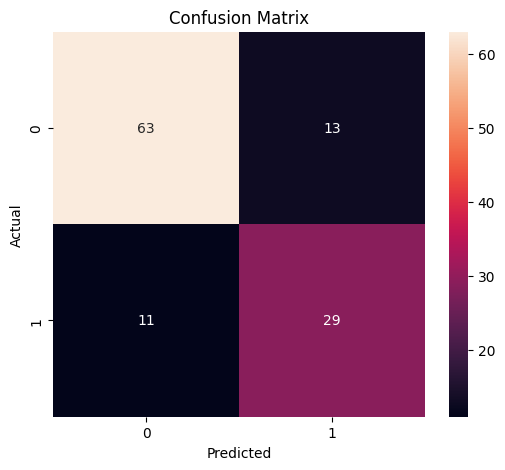

In [91]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [92]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_preds))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84        76
           1       0.69      0.72      0.71        40

    accuracy                           0.79       116
   macro avg       0.77      0.78      0.77       116
weighted avg       0.80      0.79      0.79       116



In [93]:
new_patient = [[
    6,      # Pregnancies
    148,    # Glucose
    72,     # BloodPressure
    35,     # SkinThickness
    0,      # Insulin
    33.6,   # BMI
    0.627,  # DiabetesPedigreeFunction
    50      # Age
]]

import joblib
from tensorflow.keras.models import load_model

# Load scaler
scaler = joblib.load("diabetes_scaler.joblib")

# Load model
model = load_model("diabetes_ann_model.keras")

# Scale input
new_patient_scaled = scaler.transform(new_patient)

# Predict probability
probability = model.predict(new_patient_scaled)[0][0]

print("Diabetes Probability:", probability)

if probability > 0.5:
    print("Prediction: Diabetic")
else:
    print("Prediction: Non-Diabetic")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Diabetes Probability: 0.804885
Prediction: Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [94]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict(X_test)

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 4))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
ROC-AUC Score: 0.8586


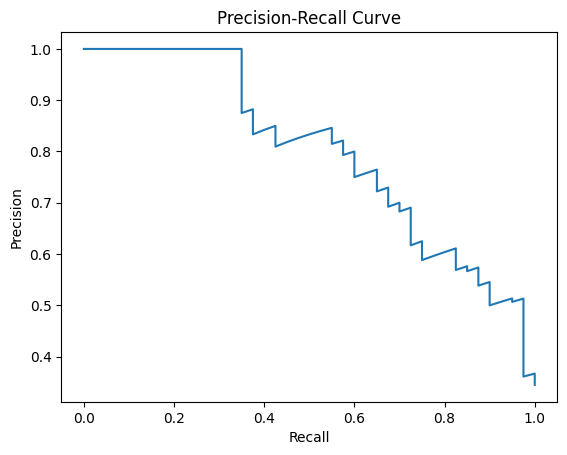

In [95]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()